<a href="https://colab.research.google.com/github/prajwalbhandari416/Solar/blob/main/Geo_Str0me_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
"""
Geomagnetic Storm Prediction using Deep Learning

Author: NeonLabs
Date: January 2026
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy.stats import pearsonr

In [ ]:
!pip install tensorflow
!pip install keras

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 620.7/620.7 MB 857.6 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.5/57.5 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 96.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 153.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 43.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 225.2/225.2 kB 16.3 MB/s eta 0:00:00


In [2]:
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (LSTM, Dense, Dropout, Bidirectional,
                                      Conv1D, MaxPooling1D, Flatten, Input,
                                      MultiHeadAttention, LayerNormalization,
                                      GlobalAveragePooling1D, Concatenate)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Adam

In [3]:

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# Configure GPU if available
physical_devices = tf.config.list_physical_devices('GPU')
if physical_devices:
    tf.config.experimental.set_memory_growth(physical_devices[0], True)
    print(f"GPU Available: {physical_devices}")
else:
    print("Running on CPU")

GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [5]:
# -----------------------------
# 1. DATA LOADING AND PREPROCESSING
# -----------------------------

class DataPreprocessor:
    """Handles all data preprocessing operations"""

    def __init__(self, filepath):
        self.filepath = filepath
        self.df = None
        self.scaler = MinMaxScaler()
        self.missing_values_map = {
            #'Bz': 9999.99,
            #'Vsw': 99999.9,
            #'nPa': 999.99,
            #'ProtonTemperature': 9999999,
            'FP': 99.99
        }

    def load_data(self):
        self.df = pd.read_csv(self.filepath)
        print(f"Dataset Shape: {self.df.shape}")
        print(f"\nColumns: {list(self.df.columns)}")
        print(f"\nFirst few rows:\n{self.df.head()}")

        return self

    def handle_missing_values(self):
        # Replace placeholder values
        for col, missing_val in self.missing_values_map.items():
            if col in self.df.columns:
                count_before = (self.df[col] == missing_val).sum()
                self.df[col] = self.df[col].replace(missing_val, np.nan)
                print(f"{col}: Replaced {count_before} placeholder values")

        # Display missing value statistics
        missing_stats = self.df.isnull().sum().sort_values(ascending=False)
        missing_pct = (missing_stats / len(self.df) * 100).round(2)

        print(f"\nMissing Values Summary:")
        for col in missing_stats[missing_stats > 0].index:
            print(f"  {col}: {missing_stats[col]} ({missing_pct[col]}%)")

        return self

    def clean_data(self, target_column='Dst'):
        # Handle time column
        if 'Time' in self.df.columns:
            self.df['Time'] = pd.to_datetime(self.df['Time'], errors='coerce')
            self.df = self.df.sort_values('Time')
            self.df = self.df.drop(columns=['Time'])

        # Convert all columns to numeric
        for col in self.df.columns:
            self.df[col] = pd.to_numeric(self.df[col], errors='coerce')

        # Forward fill then backward fill missing values
        self.df = self.df.fillna(method='ffill').fillna(method='bfill')

        # Drop any remaining NaN rows
        initial_shape = self.df.shape[0]
        self.df = self.df.dropna()
        dropped_rows = initial_shape - self.df.shape[0]

        print(f"Rows dropped: {dropped_rows}")
        print(f"Final dataset shape: {self.df.shape}")
        print(f"\nData types:\n{self.df.dtypes}")

        return self

    def get_processed_data(self):
        """Return processed dataframe"""
        return self.df

In [7]:



# -----------------------------
# 2. SEQUENCE GENERATION
# -----------------------------

class SequenceGenerator:
    """Creates sequences for time series prediction"""

    def __init__(self, data, target_column='Dst', lookback=48):
        self.data = data
        self.target_column = target_column
        self.lookback = lookback
        self.scaler = MinMaxScaler()

    def create_sequences(self):
        """Create input-output sequences"""
        print("\n" + "=" * 70)
        print("CREATING SEQUENCES")
        print("=" * 70)

        # Scale the data
        scaled_data = self.scaler.fit_transform(self.data)
        target_index = self.data.columns.get_loc(self.target_column)

        X, y = [], []
        for i in range(len(scaled_data) - self.lookback):
            X.append(scaled_data[i:i + self.lookback])
            y.append(scaled_data[i + self.lookback, target_index])

        X = np.array(X)
        y = np.array(y)

        print(f"Sequence shape: {X.shape}")
        print(f"Target shape: {y.shape}")
        print(f"Features: {X.shape[2]}")
        print(f"Lookback: {self.lookback} hours")

        return X, y

    def split_data(self, X, y, test_size=0.2, val_size=0.1):
        # First split: train+val and test
        split_idx = int(len(X) * (1 - test_size))
        X_temp, X_test = X[:split_idx], X[split_idx:]
        y_temp, y_test = y[:split_idx], y[split_idx:]

        # Second split: train and validation
        val_split_idx = int(len(X_temp) * (1 - val_size / (1 - test_size)))
        X_train, X_val = X_temp[:val_split_idx], X_temp[val_split_idx:]
        y_train, y_val = y_temp[:val_split_idx], y_temp[val_split_idx:]

        print(f"Train set: {X_train.shape[0]} samples")
        print(f"Validation set: {X_val.shape[0]} samples")
        print(f"Test set: {X_test.shape[0]} samples")

        return X_train, X_val, X_test, y_train, y_val, y_test


# -----------------------------
# 3. MODEL ARCHITECTURES
# -----------------------------

class ModelFactory:
    """Factory for creating different model architectures"""

    @staticmethod
    def build_lstm(input_shape, units=[64, 32], dropout=0.2):
        """Standard LSTM model"""
        model = Sequential([
            LSTM(units[0], return_sequences=True, input_shape=input_shape),
            Dropout(dropout),
            LSTM(units[1]),
            Dropout(dropout),
            Dense(1)
        ])
        return model

    @staticmethod
    def build_bidirectional_lstm(input_shape, units=[64, 32], dropout=0.2):
        """Bidirectional LSTM - captures patterns in both directions"""
        model = Sequential([
            Bidirectional(LSTM(units[0], return_sequences=True), input_shape=input_shape),
            Dropout(dropout),
            Bidirectional(LSTM(units[1])),
            Dropout(dropout),
            Dense(1)
        ])
        return model

    @staticmethod
    def build_cnn_lstm(input_shape, filters=64, kernel_size=3, lstm_units=50, dropout=0.2):
        """CNN-LSTM Hybrid - CNNs extract features, LSTM captures temporal dependencies"""
        model = Sequential([
            Conv1D(filters=filters, kernel_size=kernel_size, activation='relu',
                   input_shape=input_shape, padding='same'),
            MaxPooling1D(pool_size=2),
            Dropout(dropout),
            LSTM(lstm_units, return_sequences=True),
            Dropout(dropout),
            LSTM(lstm_units // 2),
            Dropout(dropout),
            Dense(1)
        ])
        return model

    @staticmethod
    def build_transformer(input_shape, head_size=256, num_heads=4, ff_dim=4,
                         num_transformer_blocks=2, mlp_units=[128], dropout=0.1):
        """Transformer model - uses self-attention mechanism"""
        inputs = Input(shape=input_shape)
        x = inputs

        for _ in range(num_transformer_blocks):
            # Multi-head attention
            attention_output = MultiHeadAttention(
                key_dim=head_size, num_heads=num_heads, dropout=dropout
            )(x, x)
            attention_output = Dropout(dropout)(attention_output)
            x = LayerNormalization(epsilon=1e-6)(x + attention_output)

            # Feed-forward network
            ff_output = Dense(ff_dim, activation='relu')(x)
            ff_output = Dropout(dropout)(ff_output)
            ff_output = Dense(input_shape[-1])(ff_output)
            x = LayerNormalization(epsilon=1e-6)(x + ff_output)

        # Global pooling and output
        x = GlobalAveragePooling1D()(x)
        for units in mlp_units:
            x = Dense(units, activation='relu')(x)
            x = Dropout(dropout)(x)
        outputs = Dense(1)(x)

        model = Model(inputs=inputs, outputs=outputs)
        return model

    @staticmethod
    def build_tcn(input_shape, nb_filters=64, kernel_size=3, nb_stacks=1,
                  dilations=[1, 2, 4, 8], dropout=0.2):
        """Temporal Convolutional Network - uses dilated convolutions"""
        inputs = Input(shape=input_shape)
        x = inputs

        for stack in range(nb_stacks):
            for dilation in dilations:
                # Residual block
                conv = Conv1D(filters=nb_filters, kernel_size=kernel_size,
                             dilation_rate=dilation, padding='causal',
                             activation='relu')(x)
                conv = Dropout(dropout)(conv)
                conv = Conv1D(filters=nb_filters, kernel_size=kernel_size,
                             dilation_rate=dilation, padding='causal',
                             activation='relu')(conv)
                conv = Dropout(dropout)(conv)

                # Match dimensions if needed
                if x.shape[-1] != nb_filters:
                    x = Conv1D(filters=nb_filters, kernel_size=1, padding='same')(x)

                x = tf.keras.layers.Add()([x, conv])
                x = tf.keras.layers.Activation('relu')(x)

        x = GlobalAveragePooling1D()(x)
        x = Dense(64, activation='relu')(x)
        x = Dropout(dropout)(x)
        outputs = Dense(1)(x)

        model = Model(inputs=inputs, outputs=outputs)
        return model

# -----------------------------
# 4. TRAINING AND EVALUATION
# -----------------------------

class ModelTrainer:
    """Handles model training and evaluation"""

    def __init__(self, model_name, model, scaler):
        self.model_name = model_name
        self.model = model
        self.scaler = scaler
        self.history = None
        self.predictions = None

    def compile_model(self, learning_rate=0.001):
        """Compile the model"""
        self.model.compile(
            optimizer=Adam(learning_rate=learning_rate),
            loss='mse',
            metrics=['mae']
        )

    def train(self, X_train, y_train, X_val, y_val, epochs=150, batch_size=32):
        callbacks = [
            EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
            ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-7),
            ModelCheckpoint(f'/content/drive/MyDrive/{self.model_name}_best.keras',
                          save_best_only=True, monitor='val_loss')
        ]

        self.history = self.model.fit(
            X_train, y_train,
            validation_data=(X_val, y_val),
            epochs=epochs,
            batch_size=batch_size,
            callbacks=callbacks,
            verbose=1
        )

        return self.history

    def evaluate(self, X_test, y_test, df, target_column='Dst'):
        # Make predictions
        y_pred_scaled = self.model.predict(X_test)

        # Inverse transform to original scale
        # Create dummy array with same features
        n_features = df.shape[1]
        target_idx = df.columns.get_loc(target_column)

        # Inverse transform predictions
        dummy_pred = np.zeros((len(y_pred_scaled), n_features))
        dummy_pred[:, target_idx] = y_pred_scaled.flatten()
        y_pred = self.scaler.inverse_transform(dummy_pred)[:, target_idx]

        # Inverse transform actual values
        dummy_actual = np.zeros((len(y_test), n_features))
        dummy_actual[:, target_idx] = y_test.flatten()
        y_actual = self.scaler.inverse_transform(dummy_actual)[:, target_idx]

        # Calculate metrics
        rmse = np.sqrt(mean_squared_error(y_actual, y_pred))
        mae = mean_absolute_error(y_actual, y_pred)
        r2 = r2_score(y_actual, y_pred)
        correlation, _ = pearsonr(y_actual, y_pred)

        # Calculate prediction efficiency (PE)
        pe = 1 - (np.sum((y_actual - y_pred) ** 2) / np.sum(y_actual ** 2))

        print(f"\nPerformance Metrics:")
        print(f"  RMSE: {rmse:.4f} nT")
        print(f"  MAE: {mae:.4f} nT")
        print(f"  R²: {r2:.4f}")
        print(f"  Correlation: {correlation:.4f}")
        print(f"  Prediction Efficiency: {pe:.4f}")

        self.predictions = {
            'actual': y_actual,
            'predicted': y_pred,
            'metrics': {
                'rmse': rmse,
                'mae': mae,
                'r2': r2,
                'correlation': correlation,
                'pe': pe
            }
        }

        return self.predictions


# -----------------------------
# 5. STORM CLASSIFICATION
# -----------------------------

class StormClassifier:
    """Converts SYMH predictions to storm classification"""

    @staticmethod
    def classify_symh(symh_values):
        """
        Classify geomagnetic storm intensity based on SYMH index

        Categories:
        - Quiet: SYMH > -30 nT
        - Minor: -50 < SYMH ≤ -30 nT
        - Moderate: -100 < SYMH ≤ -50 nT
        - Intense: -200 < SYMH ≤ -100 nT
        - Super Storm: SYMH ≤ -200 nT
        """
        categories = []
        for val in symh_values:
            if val > -30:
                categories.append('Quiet')
            elif val > -50:
                categories.append('Minor')
            elif val > -100:
                categories.append('Moderate')
            elif val > -200:
                categories.append('Intense')
            else:
                categories.append('Super Storm')
        return np.array(categories)

    @staticmethod
    def evaluate_classification(y_actual, y_pred):
        """Evaluate storm classification performance"""
        from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

        actual_classes = StormClassifier.classify_symh(y_actual)
        pred_classes = StormClassifier.classify_symh(y_pred)

        print("\n" + "=" * 70)
        print("STORM CLASSIFICATION ANALYSIS")
        print("=" * 70)

        print(f"\nAccuracy: {accuracy_score(actual_classes, pred_classes):.4f}")
        print(f"\nClassification Report:")
        print(classification_report(actual_classes, pred_classes))

        print(f"\nConfusion Matrix:")
        cm = confusion_matrix(actual_classes, pred_classes)
        print(cm)

        return actual_classes, pred_classes, cm


# -----------------------------
# 6. VISUALIZATION
# -----------------------------

class Visualizer:
    """Create comprehensive visualizations"""

    @staticmethod
    def plot_training_history(histories, model_names):
        """Plot training history for all models"""
        fig, axes = plt.subplots(1, 2, figsize=(15, 5))

        for history, name in zip(histories, model_names):
            axes[0].plot(history.history['loss'], label=f'{name} - Train')
            axes[0].plot(history.history['val_loss'], label=f'{name} - Val', linestyle='--')

        axes[0].set_xlabel('Epoch')
        axes[0].set_ylabel('Loss (MSE)')
        axes[0].set_title('Training and Validation Loss')
        axes[0].legend()
        axes[0].grid(True, alpha=0.3)

        for history, name in zip(histories, model_names):
            if 'mae' in history.history:
                axes[1].plot(history.history['mae'], label=f'{name} - Train')
                axes[1].plot(history.history['val_mae'], label=f'{name} - Val', linestyle='--')

        axes[1].set_xlabel('Epoch')
        axes[1].set_ylabel('MAE')
        axes[1].set_title('Training and Validation MAE')
        axes[1].legend()
        axes[1].grid(True, alpha=0.3)

        plt.tight_layout()
        plt.savefig('/content/drive/MyDrive/training_history.png', dpi=300, bbox_inches='tight')
        plt.show()

    @staticmethod
    def plot_predictions(predictions_dict, sample_size=1000):
        """Plot predictions vs actual for all models"""
        n_models = len(predictions_dict)
        fig, axes = plt.subplots(n_models, 1, figsize=(15, 5*n_models))

        if n_models == 1:
            axes = [axes]

        for idx, (model_name, pred_data) in enumerate(predictions_dict.items()):
            actual = pred_data['actual'][:sample_size]
            predicted = pred_data['predicted'][:sample_size]
            metrics = pred_data['metrics']

            axes[idx].plot(actual, label='Actual SYMH', linewidth=1.5, alpha=0.7)
            axes[idx].plot(predicted, label='Predicted SYMH', linewidth=1.5, alpha=0.7)
            axes[idx].axhline(y=-50, color='orange', linestyle='--', alpha=0.5, label='Moderate Storm')
            axes[idx].axhline(y=-100, color='red', linestyle='--', alpha=0.5, label='Intense Storm')

            axes[idx].set_xlabel('Time Step')
            axes[idx].set_ylabel('SYMH (nT)')
            axes[idx].set_title(f'{model_name} - RMSE: {metrics["rmse"]:.2f}, Corr: {metrics["correlation"]:.4f}')
            axes[idx].legend()
            axes[idx].grid(True, alpha=0.3)

        plt.tight_layout()
        plt.savefig('/content/drive/MyDrive/predictions_comparison.png', dpi=300, bbox_inches='tight')
        plt.show()

    @staticmethod
    def plot_scatter(predictions_dict):
        """Create scatter plots for all models"""
        n_models = len(predictions_dict)
        cols = 3
        rows = (n_models + cols - 1) // cols

        fig, axes = plt.subplots(rows, cols, figsize=(15, 5*rows))
        axes = axes.flatten() if n_models > 1 else [axes]

        for idx, (model_name, pred_data) in enumerate(predictions_dict.items()):
            actual = pred_data['actual']
            predicted = pred_data['predicted']
            metrics = pred_data['metrics']

            axes[idx].scatter(actual, predicted, alpha=0.5, s=10)
            axes[idx].plot([actual.min(), actual.max()],
                          [actual.min(), actual.max()],
                          'r--', linewidth=2, label='Perfect Prediction')

            axes[idx].set_xlabel('Actual SYMH (nT)')
            axes[idx].set_ylabel('Predicted SYMH (nT)')
            axes[idx].set_title(f'{model_name}\nR² = {metrics["r2"]:.4f}')
            axes[idx].legend()
            axes[idx].grid(True, alpha=0.3)

        # Hide extra subplots
        for idx in range(n_models, len(axes)):
            axes[idx].axis('off')

        plt.tight_layout()
        plt.savefig('/content/drive/MyDrive/scatter_plots.png', dpi=300, bbox_inches='tight')
        plt.show()

    @staticmethod
    def plot_residuals(predictions_dict):
        """Plot residual analysis"""
        n_models = len(predictions_dict)
        fig, axes = plt.subplots(n_models, 2, figsize=(15, 5*n_models))

        if n_models == 1:
            axes = axes.reshape(1, -1)

        for idx, (model_name, pred_data) in enumerate(predictions_dict.items()):
            actual = pred_data['actual']
            predicted = pred_data['predicted']
            residuals = actual - predicted

            # Residuals vs Predicted
            axes[idx, 0].scatter(predicted, residuals, alpha=0.5, s=10)
            axes[idx, 0].axhline(y=0, color='r', linestyle='--', linewidth=2)
            axes[idx, 0].set_xlabel('Predicted SYMH (nT)')
            axes[idx, 0].set_ylabel('Residuals (nT)')
            axes[idx, 0].set_title(f'{model_name} - Residual Plot')
            axes[idx, 0].grid(True, alpha=0.3)

            # Residuals histogram
            axes[idx, 1].hist(residuals, bins=50, edgecolor='black', alpha=0.7)
            axes[idx, 1].axvline(x=0, color='r', linestyle='--', linewidth=2)
            axes[idx, 1].set_xlabel('Residuals (nT)')
            axes[idx, 1].set_ylabel('Frequency')
            axes[idx, 1].set_title(f'{model_name} - Residual Distribution')
            axes[idx, 1].grid(True, alpha=0.3)

        plt.tight_layout()
        plt.savefig('/content/drive/MyDrive/residual_analysis.png', dpi=300, bbox_inches='tight')
        plt.show()

    @staticmethod
    def plot_confusion_matrix(cm, categories, model_name):
        """Plot confusion matrix for storm classification"""
        plt.figure(figsize=(10, 8))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                   xticklabels=categories, yticklabels=categories)
        plt.title(f'{model_name} - Storm Classification Confusion Matrix')
        plt.ylabel('Actual')
        plt.xlabel('Predicted')
        plt.tight_layout()
        plt.savefig(f'/content/drive/MyDrive/confusion_matrix_{model_name}.png',
                   dpi=300, bbox_inches='tight')
        plt.show()

    @staticmethod
    def create_comparison_table(predictions_dict):
        """Create comparison table of all models"""
        data = []
        for model_name, pred_data in predictions_dict.items():
            metrics = pred_data['metrics']
            data.append({
                'Model': model_name,
                'RMSE (nT)': f"{metrics['rmse']:.4f}",
                'MAE (nT)': f"{metrics['mae']:.4f}",
                'R²': f"{metrics['r2']:.4f}",
                'Correlation': f"{metrics['correlation']:.4f}",
                'PE': f"{metrics['pe']:.4f}"
            })

        df_results = pd.DataFrame(data)
        print("\n" + "=" * 70)
        print("MODEL COMPARISON")
        print("=" * 70)
        print(df_results.to_string(index=False))

        # Save to CSV
        df_results.to_csv('/content/drive/MyDrive/model_comparison.csv', index=False)

        return df_results

In [8]:
# MAIN
# -----------------------------

def main():
    # 1. Load and preprocess data
    preprocessor = DataPreprocessor('Sun data.csv')
    preprocessor.load_data().handle_missing_values().clean_data()
    df = preprocessor.get_processed_data()

    # 2. Create sequences
    seq_gen = SequenceGenerator(df, target_column='Dst', lookback=48)
    X, y = seq_gen.create_sequences()
    X_train, X_val, X_test, y_train, y_val, y_test = seq_gen.split_data(X, y)

    # 3. Define models to train
    input_shape = (X_train.shape[1], X_train.shape[2])

    models_config = {
        'LSTM': ModelFactory.build_lstm(input_shape),
        'BiLSTM': ModelFactory.build_bidirectional_lstm(input_shape),
        'CNN-LSTM': ModelFactory.build_cnn_lstm(input_shape),
        'Transformer': ModelFactory.build_transformer(input_shape),
        'TCN': ModelFactory.build_tcn(input_shape)
    }

    # 4. Train and evaluate all models
    histories = []
    predictions_dict = {}

    for model_name, model in models_config.items():
        trainer = ModelTrainer(model_name, model, seq_gen.scaler)
        trainer.compile_model()

        print(f"\n{model_name} Architecture:")
        model.summary()

        history = trainer.train(X_train, y_train, X_val, y_val, epochs=50, batch_size=32)
        predictions = trainer.evaluate(X_test, y_test, df)

        histories.append(history)
        predictions_dict[model_name] = predictions

    # 5. Visualizations
    print("GENERATING VISUALIZATIONS")
    print("=" * 70)

    Visualizer.plot_training_history(histories, list(models_config.keys()))
    Visualizer.plot_predictions(predictions_dict)
    Visualizer.plot_scatter(predictions_dict)
    Visualizer.plot_residuals(predictions_dict)

    # 6. Model comparison
    comparison_df = Visualizer.create_comparison_table(predictions_dict)

    # 7. Storm classification (using best model)
    best_model_name = comparison_df.loc[comparison_df['RMSE (nT)'].astype(float).idxmin(), 'Model']
    best_predictions = predictions_dict[best_model_name]

    actual_classes, pred_classes, cm = StormClassifier.evaluate_classification(
        best_predictions['actual'],
        best_predictions['predicted']
    )

    categories = ['Intense', 'Minor', 'Moderate', 'Quiet', 'Super Storm']
    Visualizer.plot_confusion_matrix(cm, categories, best_model_name)

    print(f"\nAll results saved to Google Drive")
    print(f"Best performing model: {best_model_name}")
    print(f"Best RMSE: {predictions_dict[best_model_name]['metrics']['rmse']:.4f} nT")

    return predictions_dict, comparison_df

Dataset Shape: (219208, 9)

Columns: ['B', 'Bx', 'By', 'Bz', 'Vt', 'FP', 'Kpt', 'Dst', 'AE']

First few rows:
     B   Bx   By   Bz   Vt    FP Kpt  Dst     AE
0  7.5 -5.6  2.5  1.0  675  2.64  53  -45  517.0
1  7.8 -4.9  3.9 -3.7  677  2.38  53  -37  313.0
2  7.6 -2.7  4.9 -2.6  708  2.21  53  -37  559.0
3  7.4 -3.9  2.9 -2.8  706  2.09  47  -41  567.0
4  7.0 -3.5  1.8 -1.4  721  2.08  47  -45  287.0
FP: Replaced 4541 placeholder values

Missing Values Summary:
  FP: 4555 (2.08%)
  AE: 16 (0.01%)
  Dst: 15 (0.01%)
  Bz: 14 (0.01%)
  Vt: 14 (0.01%)
  Kpt: 14 (0.01%)
  Bx: 11 (0.01%)
  By: 11 (0.01%)
  B: 9 (0.0%)
Rows dropped: 0
Final dataset shape: (219208, 9)

Data types:
B      float64
Bx     float64
By     float64
Bz     float64
Vt     float64
FP     float64
Kpt    float64
Dst    float64
AE     float64
dtype: object

CREATING SEQUENCES
Sequence shape: (219160, 48, 9)
Target shape: (219160,)
Features: 9
Lookback: 48 hours
Train set: 153412 samples
Validation set: 21916 samples
Test s

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 48, 64)         │        18,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 48, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,393 (122.63 KB)

 Trainable params: 31,393 (122.63 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 48, 9)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 48, 64)    │      1,792 │ input_layer_4[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_14          │ (None, 48, 64)    │          0 │ conv1d_1[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 48, 64)    │     12,352 │ dropout_14[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 48, 64)    │        640 │ input_layer_4[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_15          │ (None, 48, 64)    │          0 │ conv1d_2[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_4 (Add)         │ (None, 48, 64)    │          0 │ conv1d_3[0][0],   │
│                     │                   │            │ dropout_15[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 48, 64)    │          0 │ add_4[0][0]       │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_4 (Conv1D)   │ (None, 48, 64)    │     12,352 │ activation[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_16          │ (None, 48, 64)    │          0 │ conv1d_4[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_5 (Conv1D)   │ (None, 48, 64)    │     12,352 │ dropout_16[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_17          │ (None, 48, 64)    │          0 │ conv1d_5[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_5 (Add)         │ (None, 48, 64)    │          0 │ activation[0][0], │
│                     │                   │            │ dropout_17[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 48, 64)    │          0 │ add_5[0][0]       │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_6 (Conv1D)   │ (None, 48, 64)    │     12,352 │ activation_1[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_18          │ (None, 48, 64)    │          0 │ conv1d_6[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_7 (Conv1D)   │ (None, 48, 64)    │     12,352 │ dropout_18[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_19          │ (None, 48, 64)    │          0 │ conv1d_7[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_6 (Add)         │ (None, 48, 64)    │          0 │ activation_1[0][… │
│                     │                   │            │ dropout_19[0][0]

 Total params: 93,121 (363.75 KB)

 Trainable params: 93,121 (363.75 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
4795/4795 ━━━━━━━━━━━━━━━━━━━━ 25s 4ms/step - loss: 0.0068 - mae: 0.0578 - val_loss: 2.7200e-04 - val_mae: 0.0111 - learning_rate: 0.0010
Epoch 2/50
4795/4795 ━━━━━━━━━━━━━━━━━━━━ 11s 2ms/step - loss: 3.9884e-04 - mae: 0.0140 - val_loss: 1.2232e-04 - val_mae: 0.0079 - learning_rate: 0.0010
Epoch 3/50
4795/4795 ━━━━━━━━━━━━━━━━━━━━ 11s 2ms/step - loss: 2.6674e-04 - mae: 0.0112 - val_loss: 1.1788e-04 - val_mae: 0.0081 - learning_rate: 0.0010
Epoch 4/50
4795/4795 ━━━━━━━━━━━━━━━━━━━━ 12s 2ms/step - loss: 2.1521e-04 - mae: 0.0099 - val_loss: 2.2357e-04 - val_mae: 0.0131 - learning_rate: 0.0010
Epoch 5/50
4795/4795 ━━━━━━━━━━━━━━━━━━━━ 12s 2ms/step - loss: 1.9632e-04 - mae: 0.0094 - val_loss: 6.6844e-05 - val_mae: 0.0059 - learning_rate: 0.0010
Epoch 6/50
4795/4795 ━━━━━━━━━━━━━━━━━━━━ 11s 2ms/step - loss: 1.8593e-04 - mae: 0.0091 - val_loss: 6.9702e-05 - val_mae: 0.0058 - learning_rate: 0.0010
Epoch 7/50
4795/4795 ━━━━━━━━━━━━━━━━━━━━ 12s 2ms/step - loss: 1.8018e-04 - mae: 0.008

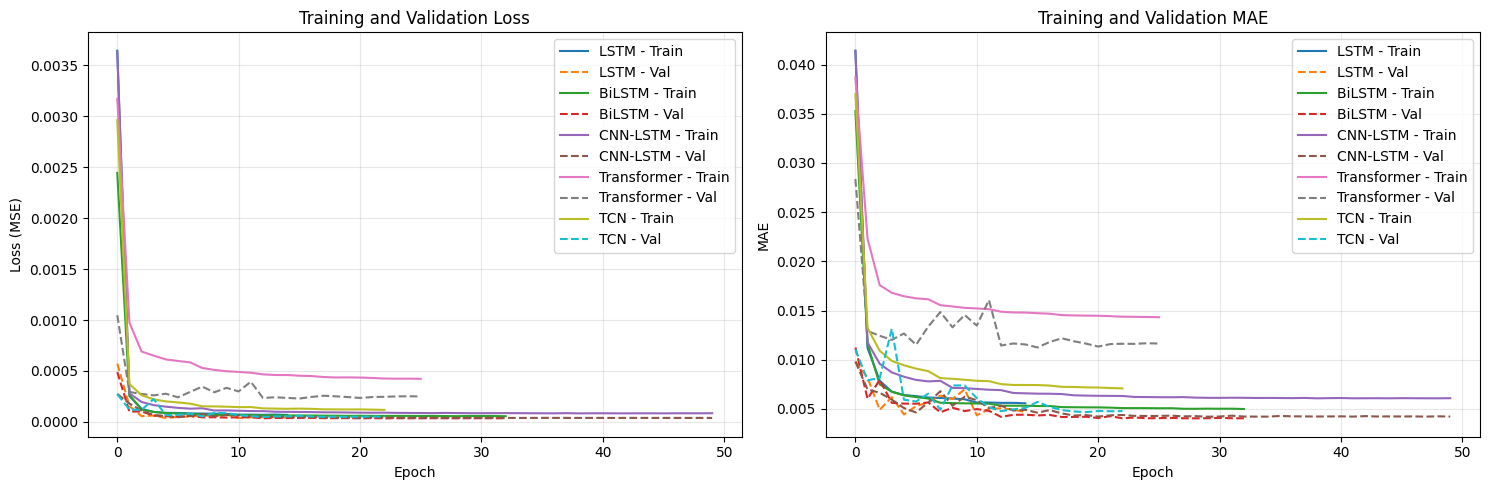

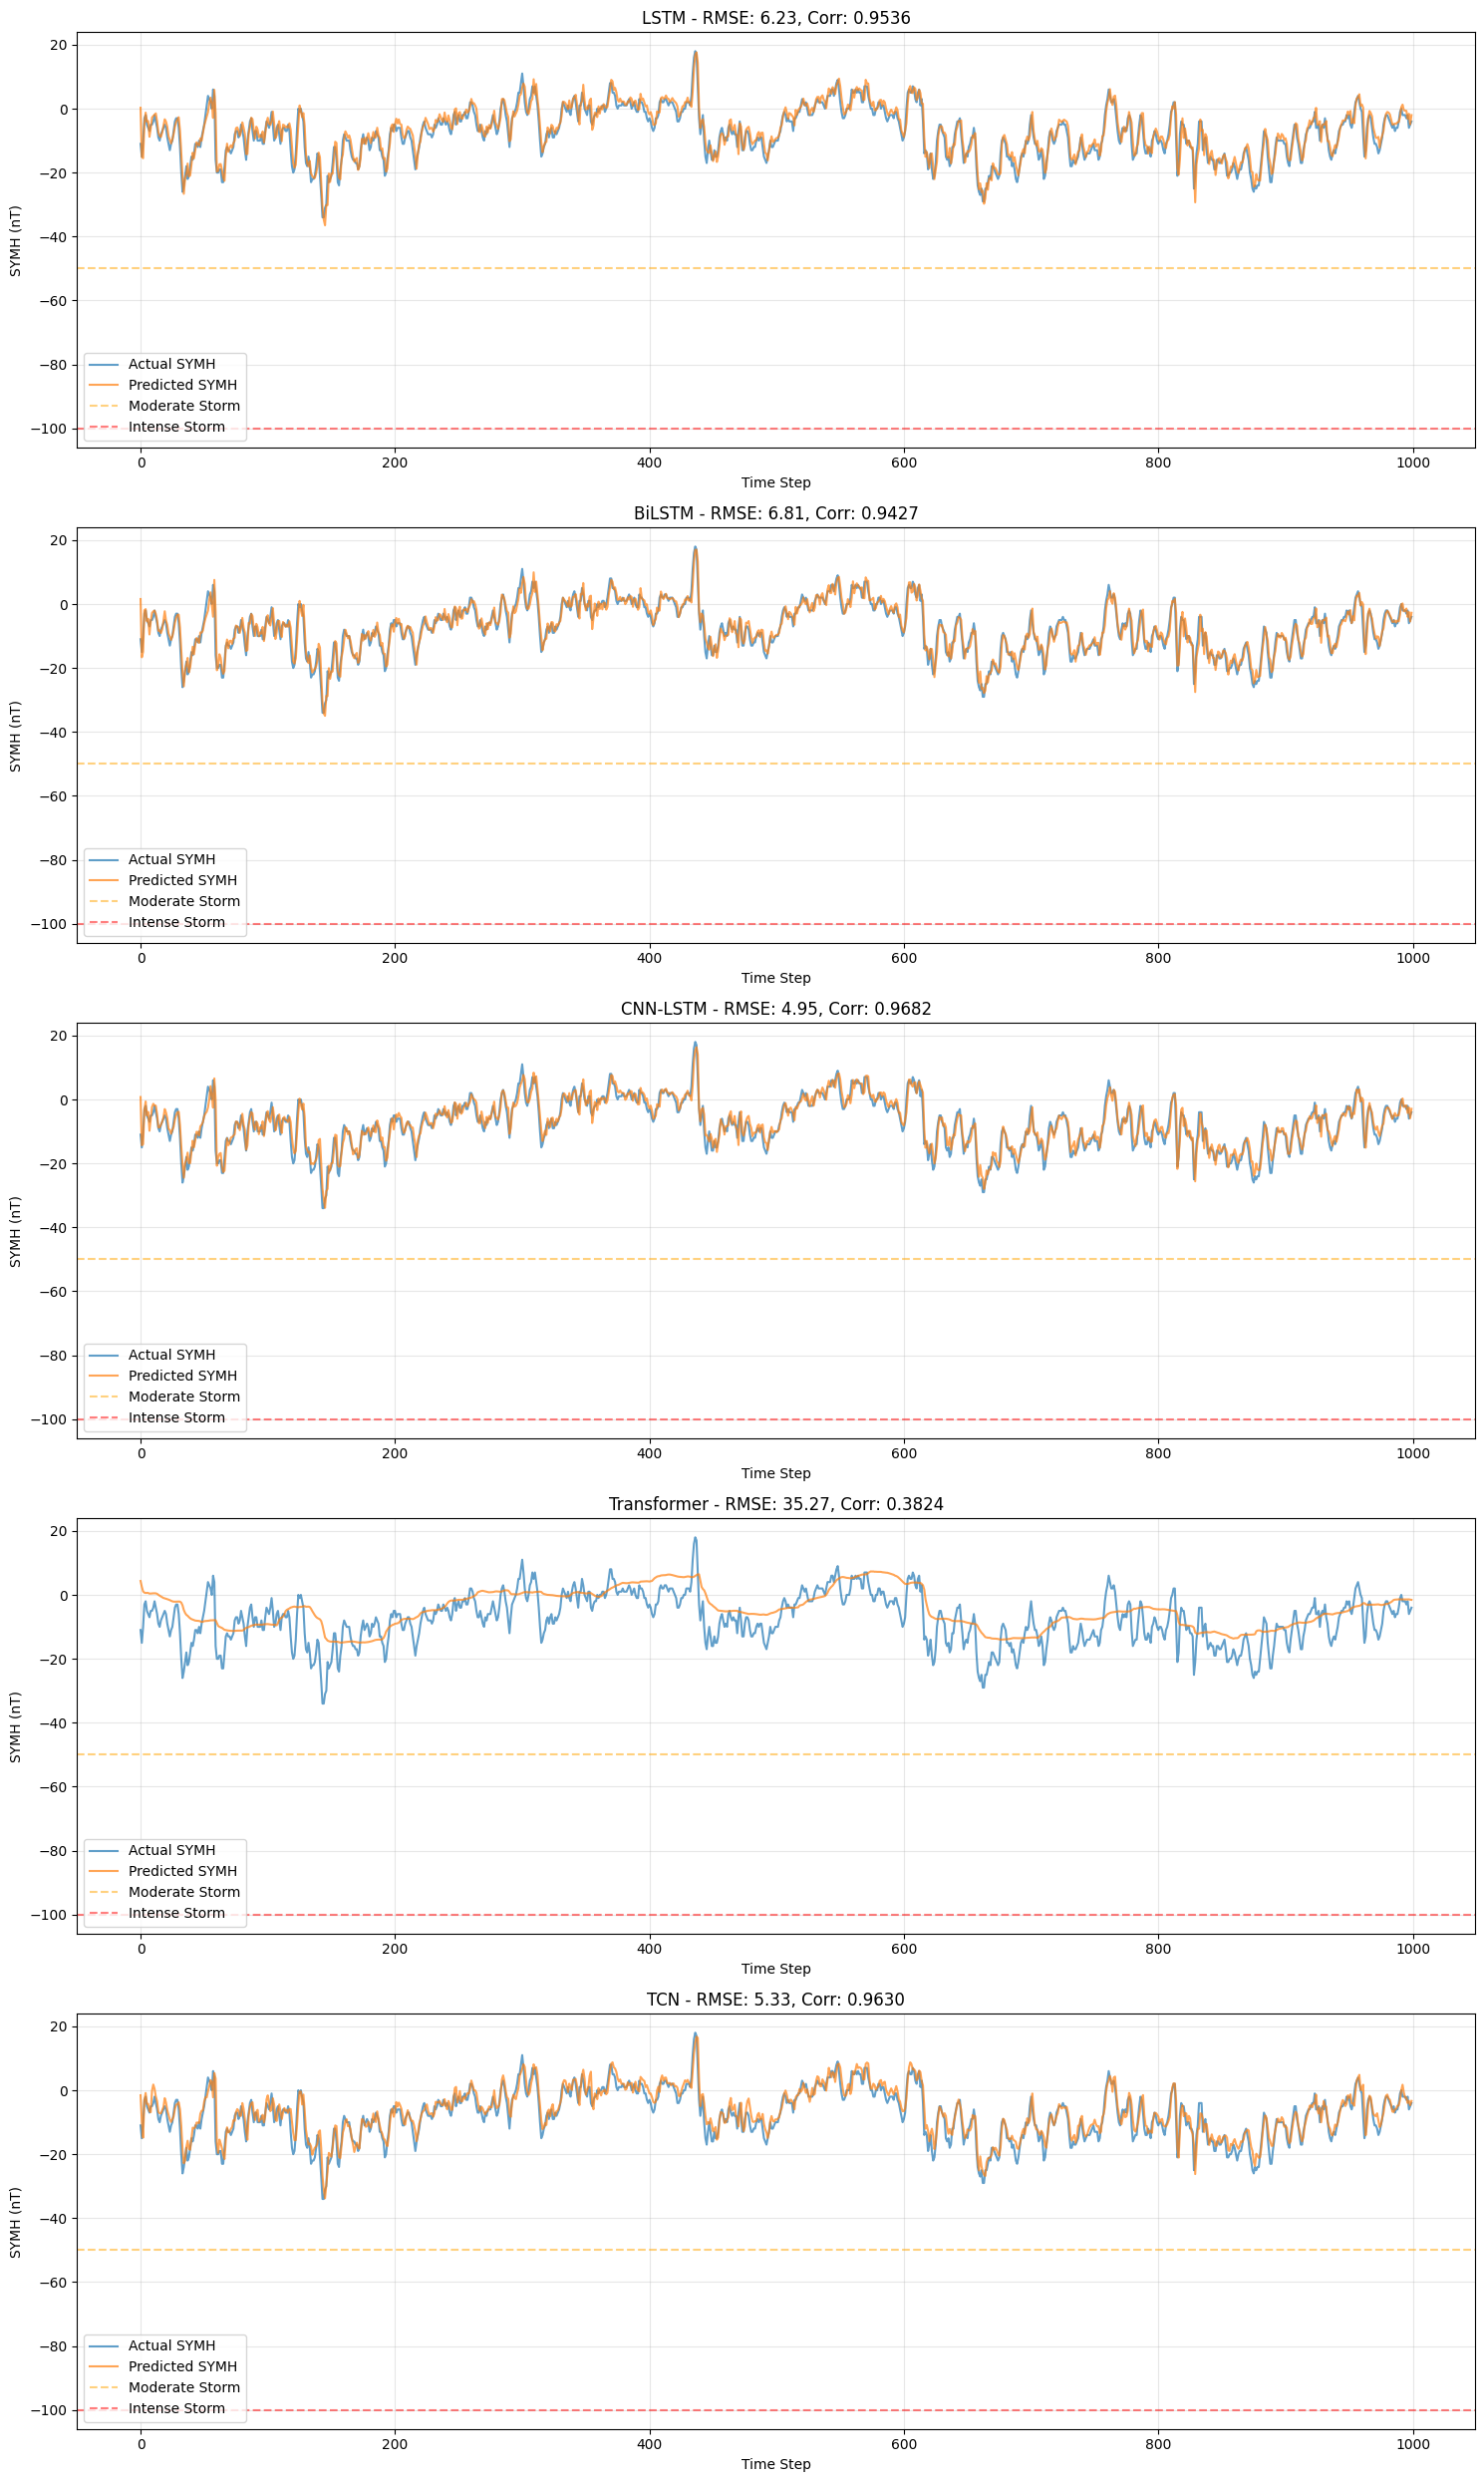

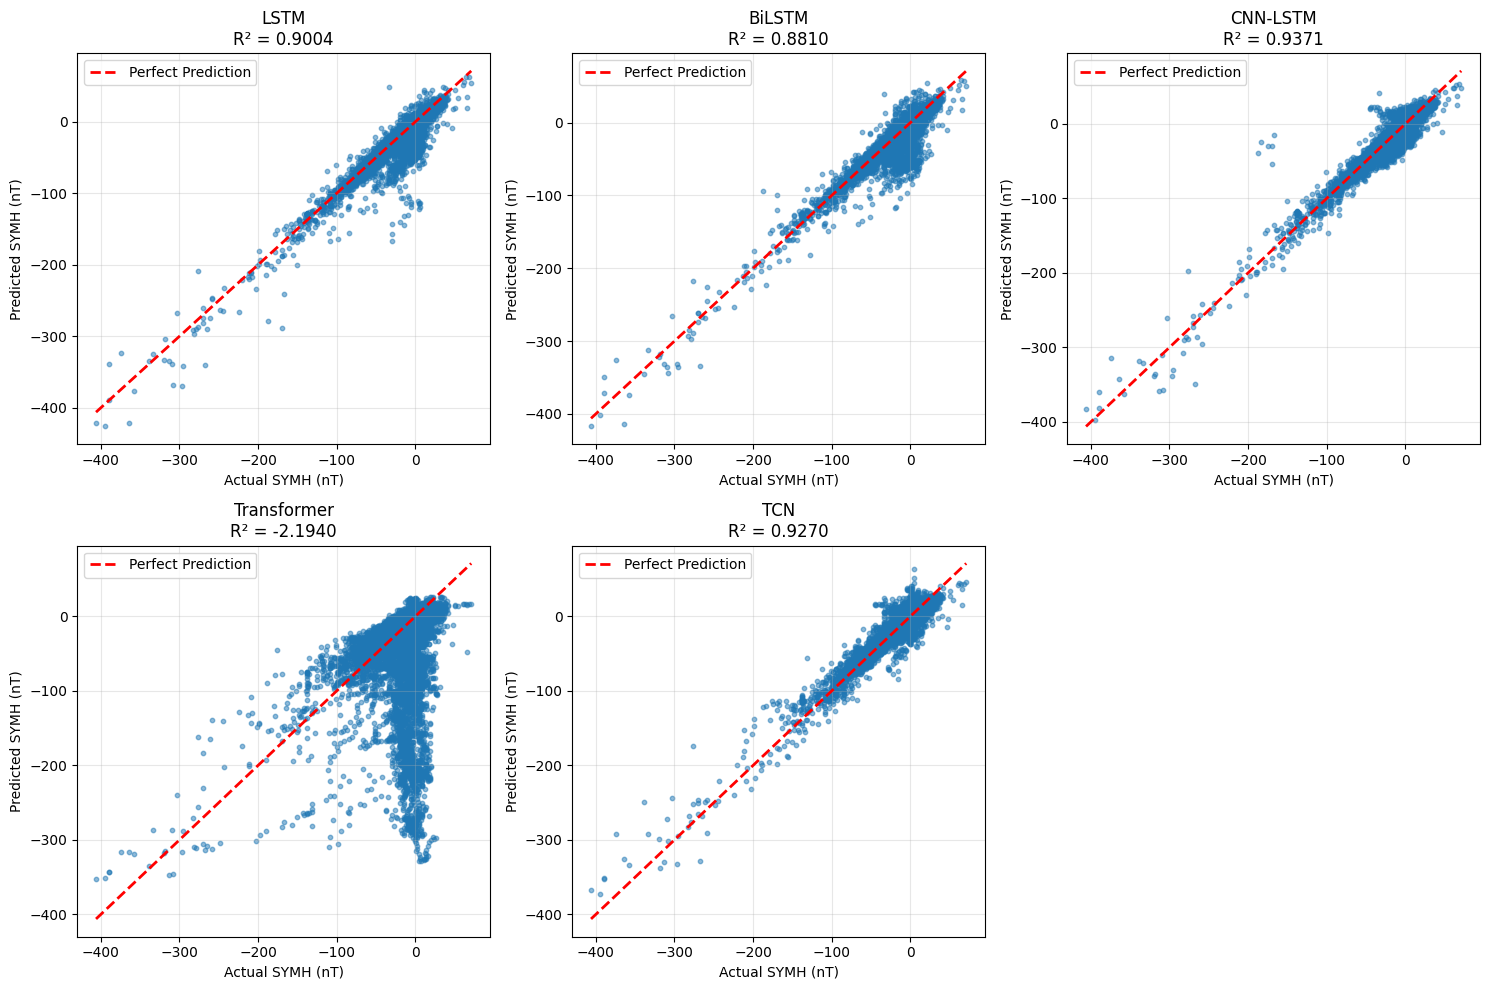

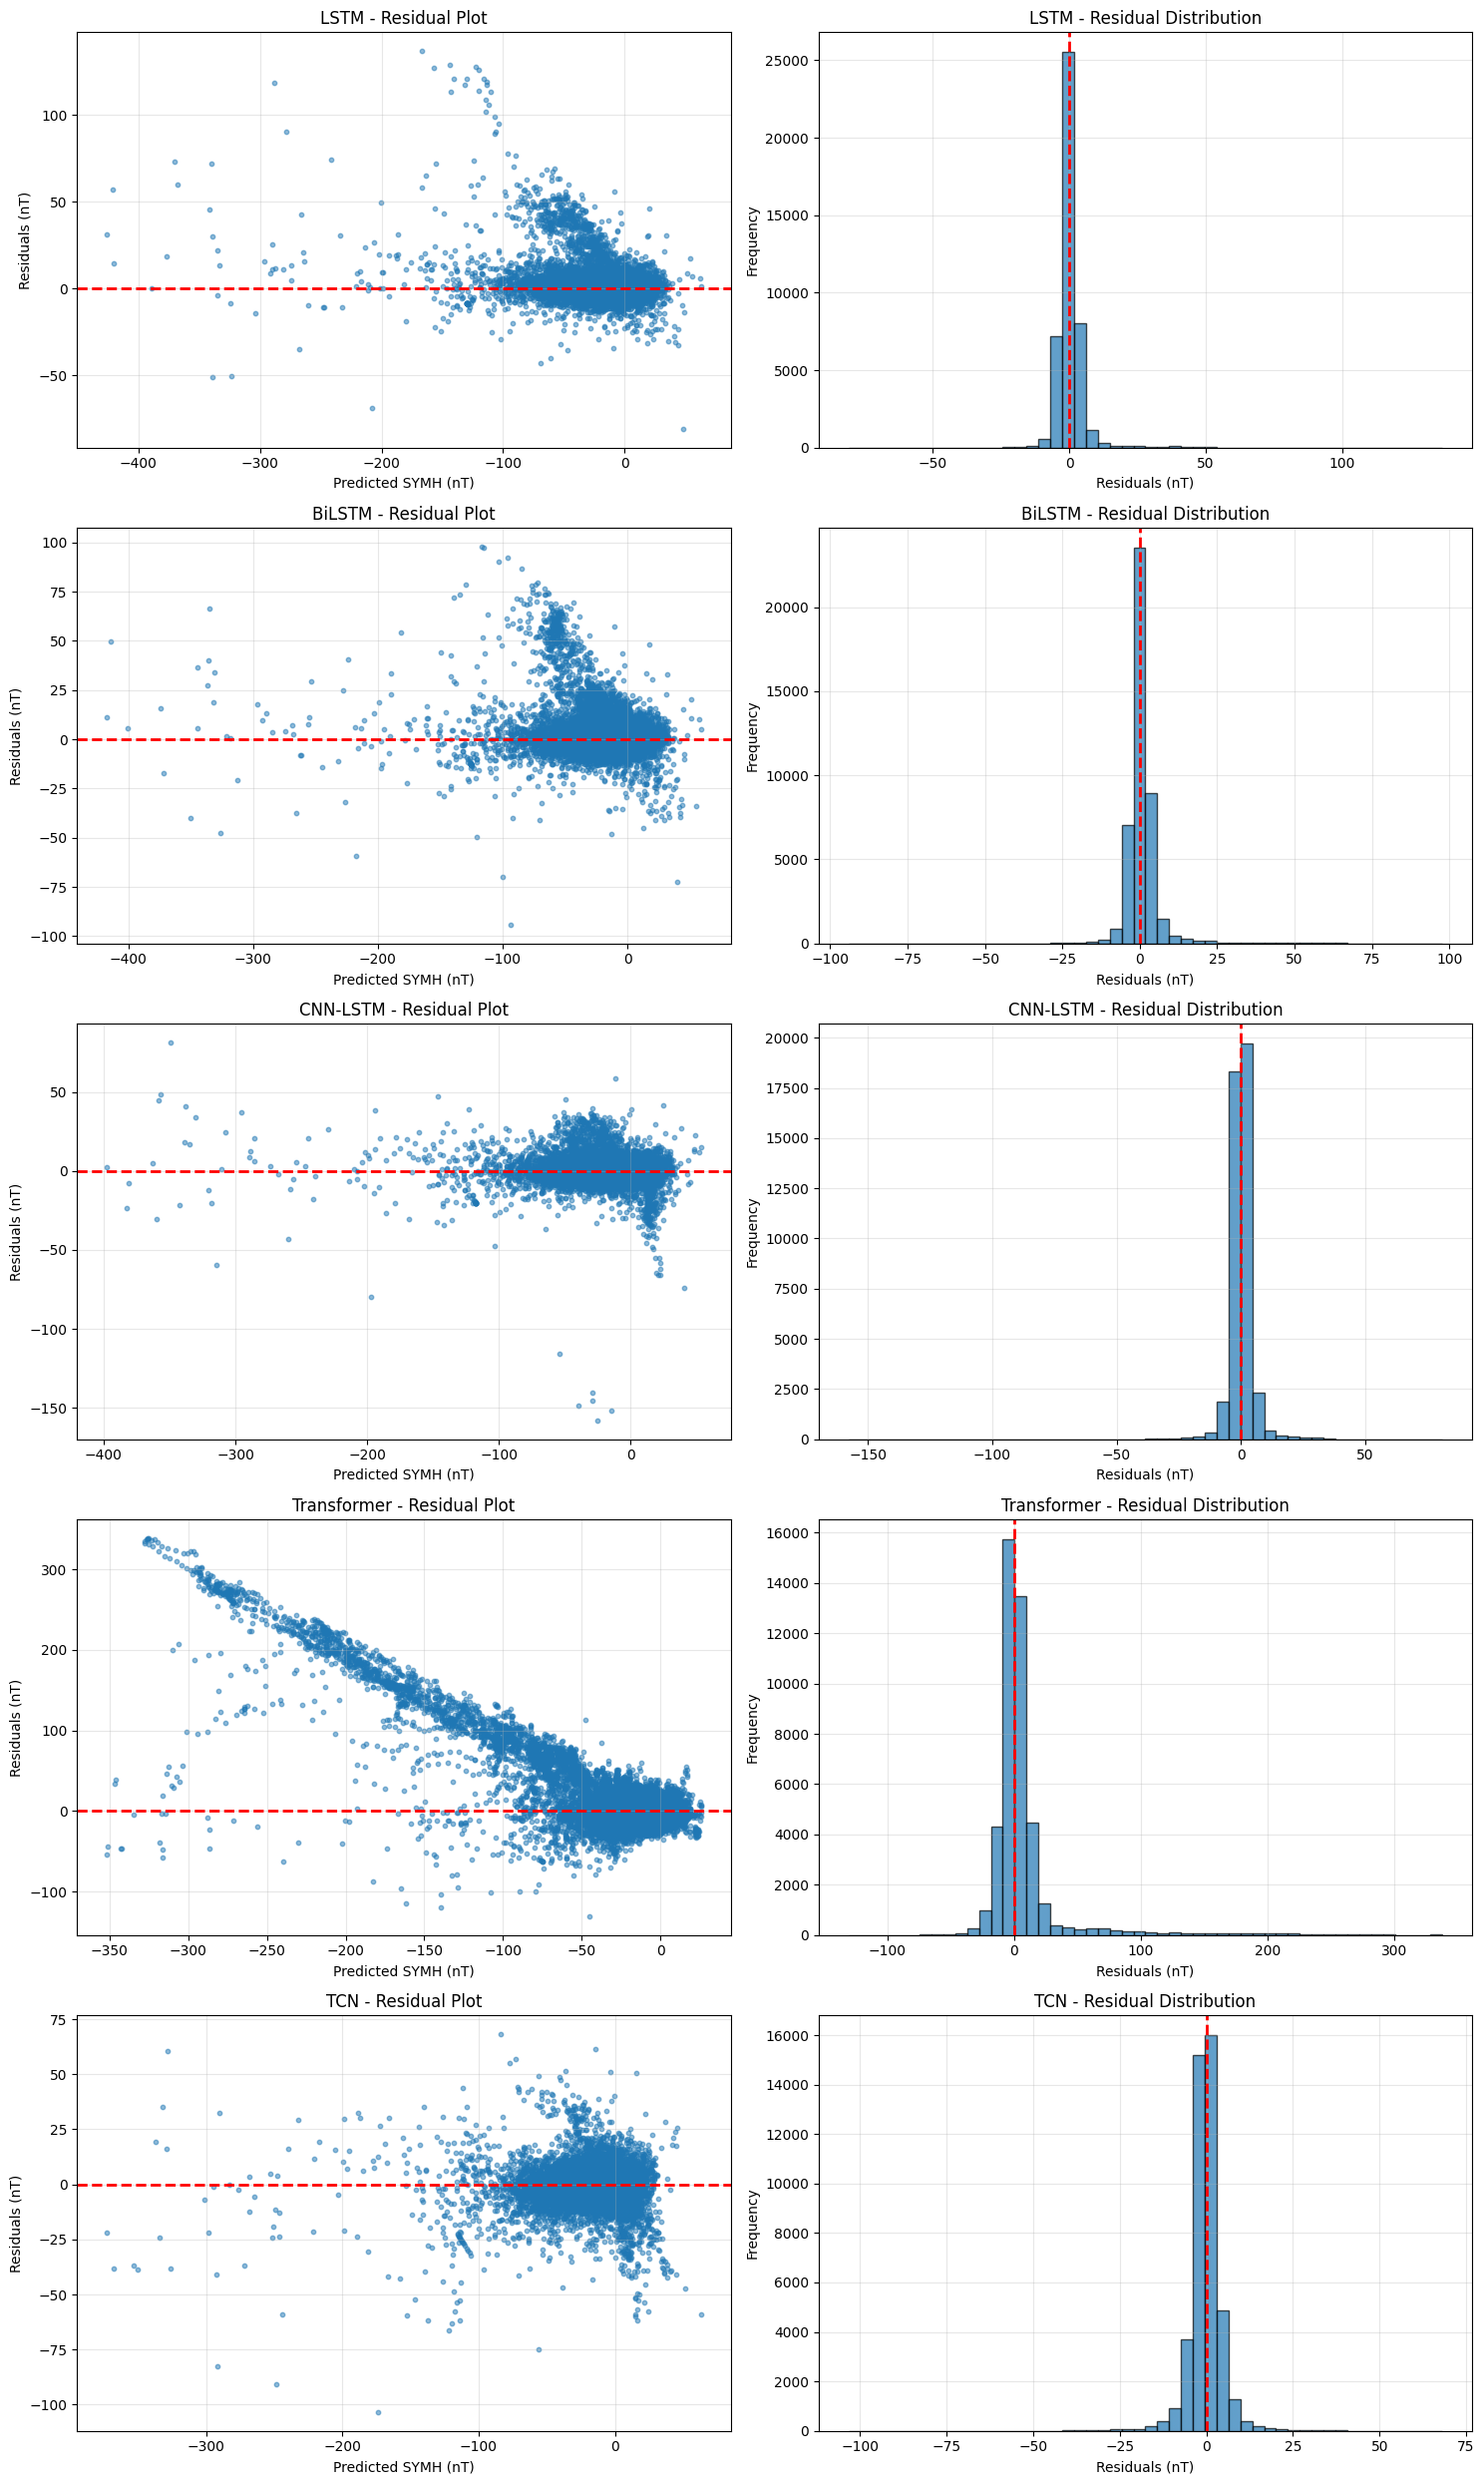


MODEL COMPARISON
      Model RMSE (nT) MAE (nT)      R² Correlation      PE
       LSTM    6.2285   2.9616  0.9004      0.9536  0.9193
     BiLSTM    6.8093   3.1286  0.8810      0.9427  0.9035
   CNN-LSTM    4.9499   2.7634  0.9371      0.9682  0.9490
Transformer   35.2742  14.3966 -2.1940      0.3824 -1.5897
        TCN    5.3339   3.1683  0.9270      0.9630  0.9408

STORM CLASSIFICATION ANALYSIS

Accuracy: 0.9705

Classification Report:
              precision    recall  f1-score   support

     Intense       0.86      0.85      0.86       185
       Minor       0.74      0.79      0.76      2496
    Moderate       0.85      0.81      0.83      1054
       Quiet       0.99      0.99      0.99     40054
 Super Storm       0.95      0.91      0.93        43

    accuracy                           0.97     43832
   macro avg       0.88      0.87      0.87     43832
weighted avg       0.97      0.97      0.97     43832


Confusion Matrix:
[[  158     1    20     4     2]
 [    0  1964 

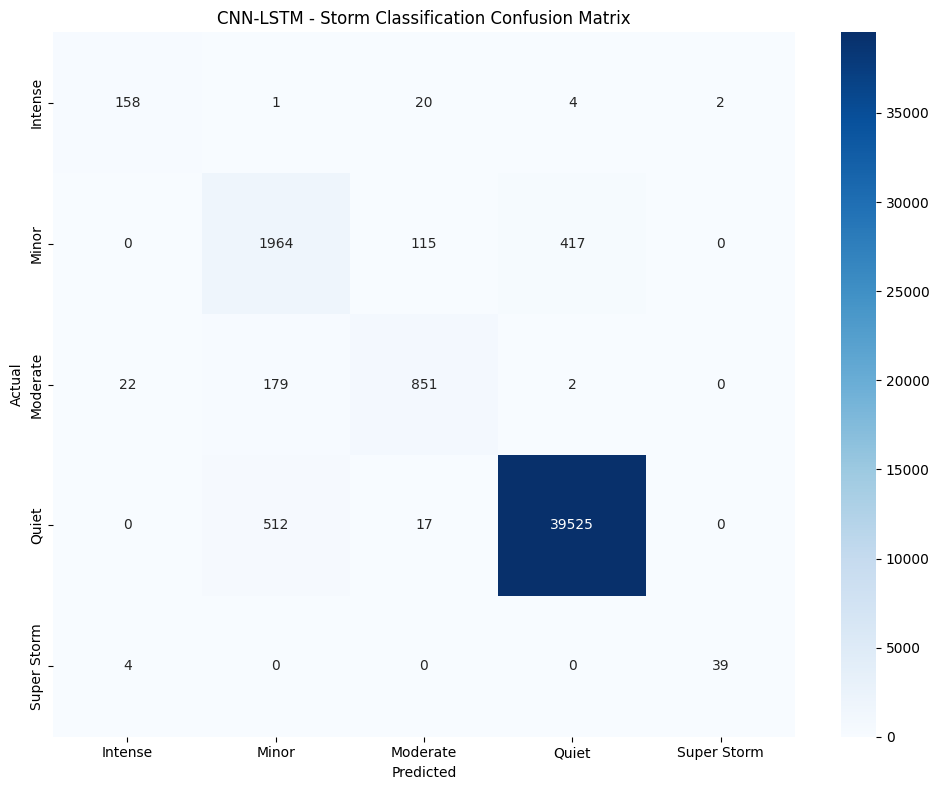


All results saved to Google Drive
Best performing model: CNN-LSTM
Best RMSE: 4.9499 nT


In [9]:
if __name__ == "__main__":
    predictions_dict, comparison_df = main()